# Suturing Quality Scoring - Production Scoring & Validation (Ticket 05)

Scores all three cohorts with the trained model (ticket 03) and the fitted
hybrid Overall aggregation (ticket 04), writes one CSV per cohort, compares
trainee levels, and runs the AI-vs-expert agreement pipeline. Expert labels
for the application cohort are not collected yet, so the agreement is
demonstrated with clearly-marked synthetic labels; the real labels slot in
unchanged when they arrive.

In [1]:
import sys
from pathlib import Path

def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start

ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from suture_scoring.data import SCORE_KEYS, load_annotations
from suture_scoring.score import fit_aggregation, score_cohort, write_csv
from suture_scoring.train import load_model
from suture_scoring.validate import agreement_by_level, load_expert_labels

TRAIN_XLSX = ROOT / "Dataset/Train/Train_cohort/Train_annotations.xlsx"
TRAIN_IMAGES = ROOT / "Dataset/Train/Train_cohort/Train"
VAL_IMAGES = ROOT / "Dataset/Val/Validation_cohort/Validation"
CHECKPOINT = ROOT / "models/resnet18-gpu.pt"
SIZE = 256  # matches the resnet18 training input
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

COHORTS = {
    "Train": TRAIN_IMAGES,
    "Val": VAL_IMAGES,
    "2week": ROOT / "Dataset/Test/Application_cohort/2week",
    "4week": ROOT / "Dataset/Test/Application_cohort/4week",
    "Resident": ROOT / "Dataset/Test/Application_cohort/Resident",
}

In [2]:
model = load_model(CHECKPOINT)
annotations = load_annotations(TRAIN_XLSX)
print("fitting the hybrid Overall aggregation on the Train cohort...")
aggregation = fit_aggregation(model, TRAIN_IMAGES, annotations, size=SIZE)
print("aggregation fitted")

fitting the hybrid Overall aggregation on the Train cohort...


aggregation fitted


In [3]:
for name, image_dir in COHORTS.items():
    rows = score_cohort(model, aggregation, image_dir, size=SIZE)
    csv_path = OUT / f"scores-{name}.csv"
    write_csv(rows, csv_path)
    print(f"{name:9s}: {len(rows)} images -> {csv_path.name}")

Train    : 1010 images -> scores-Train.csv


Val      : 206 images -> scores-Val.csv


2week    : 160 images -> scores-2week.csv


4week    : 160 images -> scores-4week.csv


Resident : 112 images -> scores-Resident.csv


In [4]:
def load_cohort(name):
    return pd.read_csv(OUT / f"scores-{name}.csv")

summary = pd.DataFrame({
    name: load_cohort(name)["Overall"].describe() for name in COHORTS
}).T.round(2)
summary[["count", "mean", "std", "min", "max"]]

,count,mean,std,min,max
Train,1010.0,5.44,1.42,2.11,8.39
Val,206.0,5.23,1.19,2.64,7.91
2week,160.0,5.61,1.15,2.91,7.96
4week,160.0,5.27,1.14,2.90,7.75
Resident,112.0,5.52,1.11,2.75,7.57


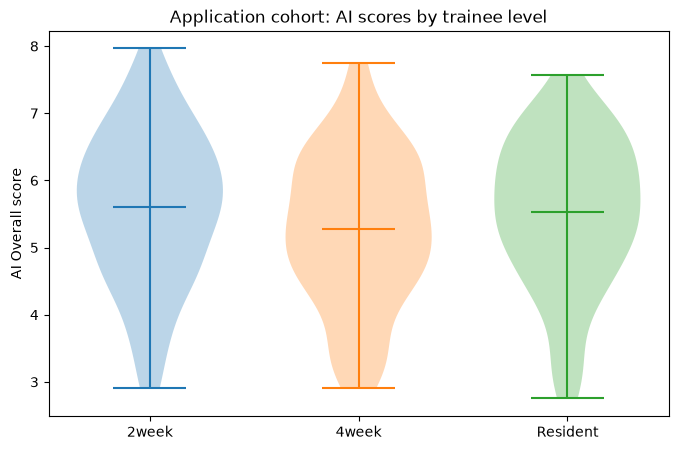

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for name in ["2week", "4week", "Resident"]:
    ax.violinplot(load_cohort(name)["Overall"], positions=[{"2week": 0, "4week": 1, "Resident": 2}[name]],
                  showmeans=True, widths=0.7)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["2week", "4week", "Resident"])
ax.set_ylabel("AI Overall score")
ax.set_title("Application cohort: AI scores by trainee level")
plt.show()

In [6]:
# External validation: use real expert labels when present; otherwise
# demonstrate the pipeline with synthetic placeholder labels.
EXPERT_XLSX = ROOT / "Dataset/Test/Application_cohort/Application_annotations.xlsx"
if EXPERT_XLSX.exists():
    labels = load_expert_labels(EXPERT_XLSX)
    print(f"expert labels found ({len(labels)} images); computing agreement against them")
else:
    print(f"expert labels not present ({EXPERT_XLSX.name}) - using synthetic placeholder labels for the demo")
    rng = np.random.default_rng(0)
    labels = {}
    for name in ["2week", "4week", "Resident"]:
        df = load_cohort(name)
        for _, row in df.iterrows():
            labels[row["filename"]] = {k: int(np.clip(round(row[k] + rng.normal(0, 0.8)), 0, 10)) for k in SCORE_KEYS}


expert labels not present (Application_annotations.xlsx) - using synthetic placeholder labels for the demo


In [7]:
scores_by_level = {name: load_cohort(name).set_index("filename")[list(SCORE_KEYS)].to_dict("index") for name in ["2week", "4week", "Resident"]}
result = agreement_by_level(scores_by_level, labels)
for level in ["2week", "4week", "Resident"]:
    print(f"--- {level} ---")
    for key in SCORE_KEYS:
        r = result[level][key]
        print(f"  {key:10s} ICC {r['icc']:.3f}  weighted-kappa {r['kappa']:.3f}")


--- 2week ---
  Overall    ICC 0.207  weighted-kappa 0.206
  ISD        ICC 0.132  weighted-kappa 0.131
  Slack      ICC 0.153  weighted-kappa 0.152
  Position   ICC 0.262  weighted-kappa 0.261
  Angulation ICC 0.042  weighted-kappa 0.042
  Width      ICC -0.032  weighted-kappa -0.031
--- 4week ---
  Overall    ICC 0.397  weighted-kappa 0.395
  ISD        ICC 0.418  weighted-kappa 0.416
  Slack      ICC 0.392  weighted-kappa 0.391
  Position   ICC 0.299  weighted-kappa 0.297
  Angulation ICC 0.267  weighted-kappa 0.266
  Width      ICC 0.213  weighted-kappa 0.212
--- Resident ---
  Overall    ICC 0.766  weighted-kappa 0.764
  ISD        ICC 0.705  weighted-kappa 0.703
  Slack      ICC 0.802  weighted-kappa 0.801
  Position   ICC 0.805  weighted-kappa 0.803
  Angulation ICC 0.621  weighted-kappa 0.618
  Width      ICC 0.321  weighted-kappa 0.319


## Status

- Per-cohort CSVs (`outputs/scores-*.csv`) are the paper's scoring output.
- The official Val split was scored but nothing was fitted on it - its labels
  are consumed once, by ticket 06, for the final reported numbers.
- Agreement tables above are **synthetic placeholders**; real expert labels
  for `Dataset/Test/Application_cohort` slot into the same pipeline unchanged.